# Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# LOAD FILE

In [9]:
file_path = "baseline.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (124035, 27)
Columns: ['image_path', 'image_id', 'species', 'common_name', 'model_kingdom', 'model_phylum', 'model_class', 'model_order', 'model_family', 'model_genus', 'score', 'top_no', 'topk_predictions_json', 'User_classified', 'user_kingdom', 'user_phylum', 'user_class', 'user_order', 'user_family', 'user_genus', 'same_kingdom?', 'same_phylum?', 'same_class?', 'same_order?', 'same_family?', 'same_genus?', 'same_species?']


# HELPER FUNCTIONS

In [10]:
def normalize_text(x):
    """
    Normalize text for comparison:
    - handle NaN
    - convert to string
    - strip spaces
    - lowercase
    - collapse repeated spaces
    """
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = " ".join(x.split())
    if x in ["", "nan", "none", "null"]:
        return np.nan
    return x

In [11]:
# def normalize_bool_false(series):
#     """
#     Robust handling in case same_species? is boolean or string.
#     Returns True for rows where same_species is False.
#     """
#     s = series.astype(str).str.strip().str.lower()
#     return s.isin(["false", "0", "no"])

In [12]:
def normalize_bool_true(series):
    """
    Robust handling in case same_species? is boolean or string.
    Returns True for rows where same_species is True.
    """
    s = series.astype(str).str.strip().str.lower()
    return s.isin(["true", "1", "yes"])

# KEEP ONLY same_species == False

In [46]:
true_df = df[normalize_bool_true(df["same_species?"])].copy()

print("\nRows with same_species == True:", len(true_df))
print("Unique image_ids in true set:", true_df["image_id"].nunique())


Rows with same_species == True: 13852
Unique image_ids in true set: 13638


In [15]:
false_df = df[~df["image_id"].isin(true_df["image_id"])].copy()
print("\nRows with same_species == False:", len(false_df))
print("Unique image_ids in false set:", false_df["image_id"].nunique())


Rows with same_species == False: 55845
Unique image_ids in false set: 11169


# DEFINE TAXONOMIC LEVEL PAIRS

In [19]:
level_pairs = {
    "kingdom": ("model_kingdom", "user_kingdom"),
    "phylum": ("model_phylum", "user_phylum"),
    "class": ("model_class", "user_class"),
    "order": ("model_order", "user_order"),
    "family": ("model_family", "user_family"),
    "genus": ("model_genus", "user_genus"),
    "species": ("species", "User_classified"),
}

In [20]:
df

,image_path,image_id,species,common_name,model_kingdom,model_phylum,model_class,model_order,model_family,model_genus,...,user_order,user_family,user_genus,same_kingdom?,same_phylum?,same_class?,same_order?,same_family?,same_genus?,same_species?
0,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Thomomys Plesiothomomys potomacensis,NaN,Animalia,Chordata,Mammalia,Rodentia,Geomyidae,Thomomys,...,Pelecaniformes,Ardeidae,Ardea,True,True,False,False,False,False,False
1,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Thomomys Plesiothomomys potomacensis,NaN,Animalia,Chordata,Mammalia,Rodentia,Geomyidae,Thomomys,...,Pelecaniformes,Ardeidae,Ardea,True,True,False,False,False,False,False
2,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Thomomys Plesiothomomys potomacensis,NaN,Animalia,Chordata,Mammalia,Rodentia,Geomyidae,Thomomys,...,Pelecaniformes,Ardeidae,Ardea,True,True,False,False,False,False,False
3,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Gillichthys mirabilis,Longjaw mudsucker,Animalia,Chordata,NaN,Perciformes,Gobiidae,Gillichthys,...,Pelecaniformes,Ardeidae,Ardea,True,True,False,False,False,False,False
4,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_341194952_photo_621071156,Gillichthys mirabilis,Longjaw mudsucker,Animalia,Chordata,NaN,Perciformes,Gobiidae,Gillichthys,...,Pelecaniformes,Ardeidae,Ardea,True,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124030,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_338604_photo_421443,Geococcyx californianus,Greater Roadrunner,Animalia,Chordata,Aves,Cuculiformes,Cuculidae,Geococcyx,...,Cuculiformes,Cuculidae,Geococcyx,True,True,True,True,True,True,True
124031,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_338604_photo_421443,Geococcyx velox,Lesser roadrunner,Animalia,Chordata,Aves,Cuculiformes,Cuculidae,Geococcyx,...,Cuculiformes,Cuculidae,Geococcyx,True,True,True,True,True,True,False
124032,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_338604_photo_421443,Campylorhynchus brunneicapillus,Cactus Wren,Animalia,Chordata,Aves,Passeriformes,Troglodytidae,Campylorhynchus,...,Cuculiformes,Cuculidae,Geococcyx,True,True,True,False,False,False,False
124033,/rs1/researchers/a/amallav/image_dataset/obs_3...,obs_338604_photo_421443,Ortygornis sephaena,Crested Francolin,Animalia,Chordata,Aves,Galliformes,Phasianidae,Ortygornis,...,Cuculiformes,Cuculidae,Geococcyx,True,True,True,False,False,False,False


In [21]:
# Check required columns exist
missing_cols = []
for level, (pred_col, user_col) in level_pairs.items():
    if pred_col not in false_df.columns:
        missing_cols.append(pred_col)
    if user_col not in false_df.columns:
        missing_cols.append(user_col)

if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(set(missing_cols))}")

In [22]:
# Check required columns exist
missing_cols = []
for level, (pred_col, user_col) in level_pairs.items():
    if pred_col not in df.columns:
        missing_cols.append(pred_col)
    if user_col not in df.columns:
        missing_cols.append(user_col)

if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(set(missing_cols))}")

In [23]:
# Check required columns exist
missing_cols = []
for level, (pred_col, user_col) in level_pairs.items():
    if pred_col not in false_df.columns:
        missing_cols.append(pred_col)
    if user_col not in false_df.columns:
        missing_cols.append(user_col)

if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(set(missing_cols))}")

# NORMALIZE VALUES + CREATE ROW-LEVEL MATCH COLUMNS

In [24]:
for level, (pred_col, user_col) in level_pairs.items():
    false_df[f"{level}_pred_norm"] = false_df[pred_col].apply(normalize_text)
    false_df[f"{level}_user_norm"] = false_df[user_col].apply(normalize_text)

    # row-level exact match only if both are present
    false_df[f"{level}_row_match"] = (
        false_df[f"{level}_pred_norm"].notna()
        & false_df[f"{level}_user_norm"].notna()
        & (false_df[f"{level}_pred_norm"] == false_df[f"{level}_user_norm"])
    )

In [25]:
for level, (pred_col, user_col) in level_pairs.items():
    df[f"{level}_pred_norm"] = df[pred_col].apply(normalize_text)
    df[f"{level}_user_norm"] = df[user_col].apply(normalize_text)

    # row-level exact match only if both are present
    df[f"{level}_row_match"] = (
        df[f"{level}_pred_norm"].notna()
        & df[f"{level}_user_norm"].notna()
        & (df[f"{level}_pred_norm"] == df[f"{level}_user_norm"])
    )

In [32]:
for level, (pred_col, user_col) in level_pairs.items():
    true_df[f"{level}_pred_norm"] = true_df[pred_col].apply(normalize_text)
    true_df[f"{level}_user_norm"] = true_df[user_col].apply(normalize_text)

    # row-level exact match only if both are present
    true_df[f"{level}_row_match"] = (
        true_df[f"{level}_pred_norm"].notna()
        & true_df[f"{level}_user_norm"].notna()
        & (true_df[f"{level}_pred_norm"] == true_df[f"{level}_user_norm"])
    )

# If one of the rows for an image_id matches, count image as matched

In [33]:
agg_dict = {}
for level in level_pairs.keys():
    agg_dict[f"{level}_row_match"] = "max"   # True if any row matches

image_true_level = true_df.groupby("image_id", as_index=False).agg(agg_dict)

# Rename columns for readability
image_true_level = image_true_level.rename(
    columns={f"{level}_row_match": f"{level}_image_match" for level in level_pairs.keys()}
)

print("\nImage-true level match table:")

print(image_true_level.head())


Image-true level match table:
                        image_id  kingdom_image_match  phylum_image_match  \
0   obs_10003229_photo_114145431                 True                True   
1  obs_100052837_photo_166933111                 True                True   
2  obs_100052837_photo_166933119                 True                True   
3  obs_100125424_photo_167070208                 True                True   
4  obs_100125424_photo_167070213                 True                True   

   class_image_match  order_image_match  family_image_match  \
0               True               True                True   
1               True               True                True   
2               True               True                True   
3               True               True                True   
4               True               True                True   

   genus_image_match  species_image_match  
0               True                 True  
1               True                 Tr

In [34]:
agg_dict = {}
for level in level_pairs.keys():
    agg_dict[f"{level}_row_match"] = "max"   # True if any row matches

image_false_level = false_df.groupby("image_id", as_index=False).agg(agg_dict)

# Rename columns for readability
image_false_level = image_false_level.rename(
    columns={f"{level}_row_match": f"{level}_image_match" for level in level_pairs.keys()}
)

print("\nImage-false level match table:")
print(image_false_level.head())


Image-false level match table:
                        image_id  kingdom_image_match  phylum_image_match  \
0  obs_100052837_photo_166933123                 True                True   
1  obs_100053359_photo_166934121                 True                True   
2  obs_100053359_photo_166934128                 True                True   
3  obs_100053594_photo_166934121                False               False   
4  obs_100053594_photo_166934128                False               False   

   class_image_match  order_image_match  family_image_match  \
0               True               True               False   
1               True              False               False   
2               True              False               False   
3              False              False               False   
4              False              False               False   

   genus_image_match  species_image_match  
0              False                False  
1              False                Fa

In [35]:
agg_dict = {}
for level in level_pairs.keys():
    agg_dict[f"{level}_row_match"] = "max"   # True if any row matches

image_whole_level = df.groupby("image_id", as_index=False).agg(agg_dict)

# Rename columns for readability
image_whole_level = image_whole_level.rename(
    columns={f"{level}_row_match": f"{level}_image_match" for level in level_pairs.keys()}
)

print("\nImage-level match table:")
print(image_whole_level)


Image-level match table:
                            image_id  kingdom_image_match  phylum_image_match  \
0       obs_10003229_photo_114145431                 True                True   
1      obs_100052837_photo_166933111                 True                True   
2      obs_100052837_photo_166933119                 True                True   
3      obs_100052837_photo_166933123                 True                True   
4      obs_100053359_photo_166934121                 True                True   
...                              ...                  ...                 ...   
24802   obs_99990955_photo_166796310                 True                True   
24803   obs_99990955_photo_166796399                 True                True   
24804   obs_99990955_photo_166796459                 True                True   
24805   obs_99990956_photo_166796339                 True                True   
24806   obs_99990956_photo_166796345                 True                True   

 

# ACCURACY BY TAXONOMIC LEVEL

In [36]:
accuracy_rows = []
n_images = len(image_false_level)

for level in level_pairs.keys():
    if level == "species": continue  # Skip species level for accuracy calculation
    match_col = f"{level}_image_match"
    matched_images = image_false_level[match_col].sum()
    accuracy = matched_images / n_images if n_images > 0 else np.nan

    accuracy_rows.append({
        "Level": level,
        "Matched_image_ids": int(matched_images),
        "Total_image_ids": int(n_images),
        "Accuracy": accuracy,
        "Accuracy_%": round(accuracy * 100, 2) if pd.notna(accuracy) else np.nan
    })

accuracy_false_df = pd.DataFrame(accuracy_rows)


print("\n=== Accuracy by Taxonomic Level (Image-level) for falsely predicted images ===")
print(accuracy_false_df.sort_values("Accuracy", ascending=False))



=== Accuracy by Taxonomic Level (Image-level) for falsely predicted images ===
     Level  Matched_image_ids  Total_image_ids  Accuracy  Accuracy_%
0  kingdom              10089            11169  0.903304       90.33
1   phylum               9689            11169  0.867490       86.75
2    class               7831            11169  0.701137       70.11
3    order               6899            11169  0.617692       61.77
4   family               6609            11169  0.591727       59.17
5    genus               4787            11169  0.428597       42.86


In [37]:
accuracy_rows = []
n_images = len(image_true_level)

for level in level_pairs.keys():
    # if level == "species": continue  # Skip species level for accuracy calculation
    match_col = f"{level}_image_match"
    matched_images = image_true_level[match_col].sum()
    accuracy = matched_images / n_images if n_images > 0 else np.nan

    accuracy_rows.append({
        "Level": level,
        "Matched_image_ids": int(matched_images),
        "Total_image_ids": int(n_images),
        "Accuracy": accuracy,
        "Accuracy_%": round(accuracy * 100, 2) if pd.notna(accuracy) else np.nan
    })

accuracy_true_df = pd.DataFrame(accuracy_rows)


print("\n=== Accuracy by Taxonomic Level (Image-level) for truly predicted images ===")
print(accuracy_true_df.sort_values("Accuracy", ascending=False))


=== Accuracy by Taxonomic Level (Image-level) for truly predicted images ===
     Level  Matched_image_ids  Total_image_ids  Accuracy  Accuracy_%
0  kingdom              13638            13638  1.000000      100.00
1   phylum              13638            13638  1.000000      100.00
6  species              13638            13638  1.000000      100.00
5    genus              13635            13638  0.999780       99.98
4   family              13292            13638  0.974630       97.46
3    order              12583            13638  0.922643       92.26
2    class              12554            13638  0.920516       92.05


In [38]:
accuracy_rows = []
n_images = len(image_whole_level)

for level in level_pairs.keys():
    # if level == "species": continue  # Skip species level for accuracy calculation
    match_col = f"{level}_image_match"
    matched_images = image_whole_level[match_col].sum()
    accuracy = matched_images / n_images if n_images > 0 else np.nan

    accuracy_rows.append({
        "Level": level,
        "Matched_image_ids": int(matched_images),
        "Total_image_ids": int(n_images),
        "Accuracy": accuracy,
        "Accuracy_%": round(accuracy * 100, 2) if pd.notna(accuracy) else np.nan
    })

accuracy_whole_df = pd.DataFrame(accuracy_rows)

print("\n=== Accuracy by Taxonomic Level (Image-level) ===")
print(accuracy_whole_df.sort_values("Accuracy", ascending=False))


=== Accuracy by Taxonomic Level (Image-level) ===
     Level  Matched_image_ids  Total_image_ids  Accuracy  Accuracy_%
0  kingdom              23727            24807  0.956464       95.65
1   phylum              23327            24807  0.940339       94.03
2    class              20385            24807  0.821744       82.17
4   family              19926            24807  0.803241       80.32
3    order              19488            24807  0.785585       78.56
5    genus              18422            24807  0.742613       74.26
6  species              13638            24807  0.549764       54.98


In [35]:
# accuracy_df.to_csv("taxonomy_accuracy_by_level.csv", index=False)
# image_level.to_csv("image_level_taxonomy_match.csv", index=False)

# print("\nSaved:")
# print("- taxonomy_accuracy_by_level.csv")
# print("- image_level_taxonomy_match.csv")

# Visualization

## BAR CHART OF ACCURACY BY LEVEL

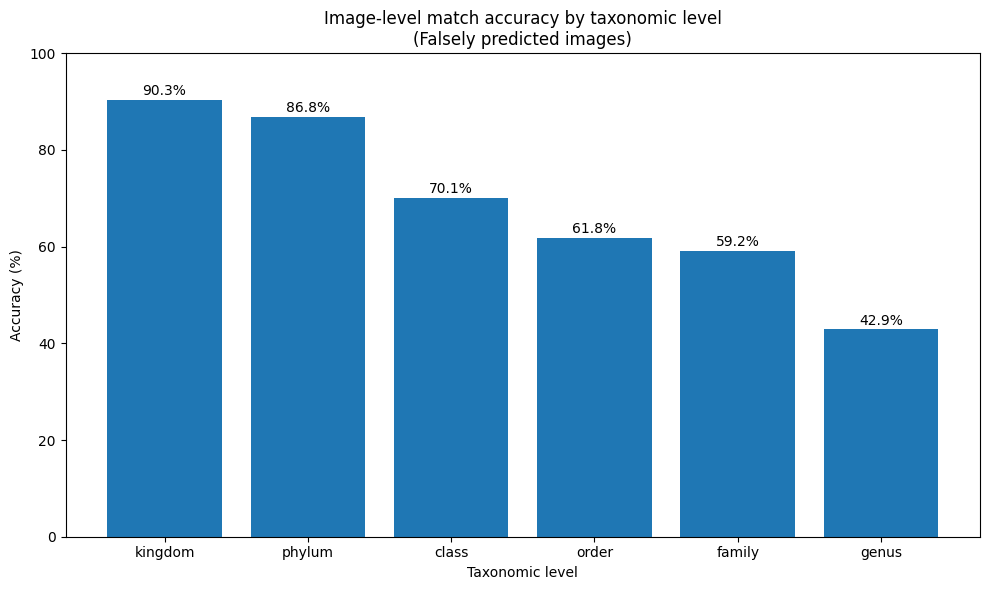

In [39]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_false_df["Level"], accuracy_false_df["Accuracy_%"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Taxonomic level")
plt.title("Image-level match accuracy by taxonomic level\n(Falsely predicted images)")
plt.ylim(0, 100)

for i, v in enumerate(accuracy_false_df["Accuracy_%"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()


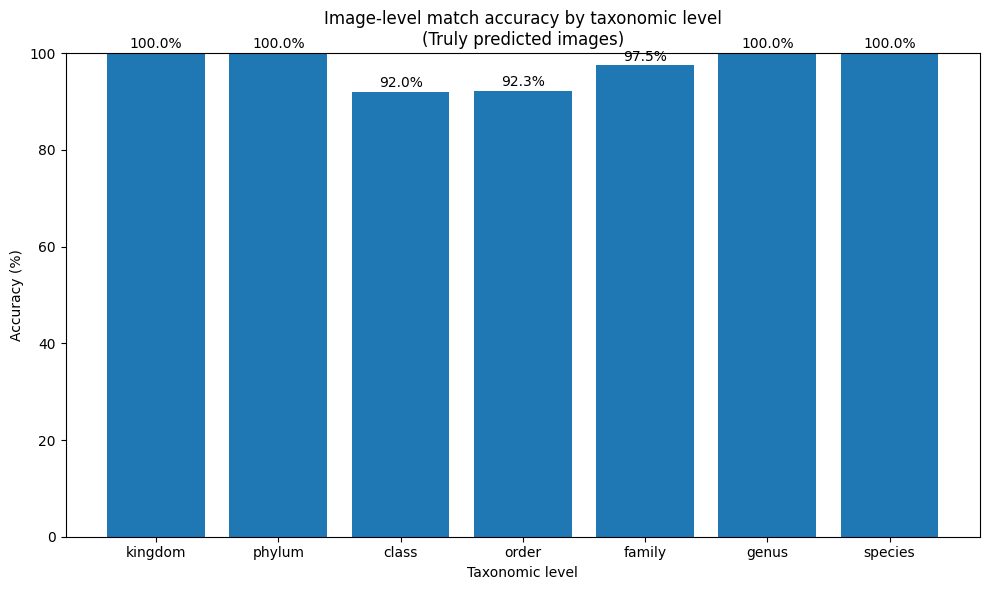

In [40]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_true_df["Level"], accuracy_true_df["Accuracy_%"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Taxonomic level")
plt.title("Image-level match accuracy by taxonomic level\n(Truly predicted images)")
plt.ylim(0, 100)

for i, v in enumerate(accuracy_true_df["Accuracy_%"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()


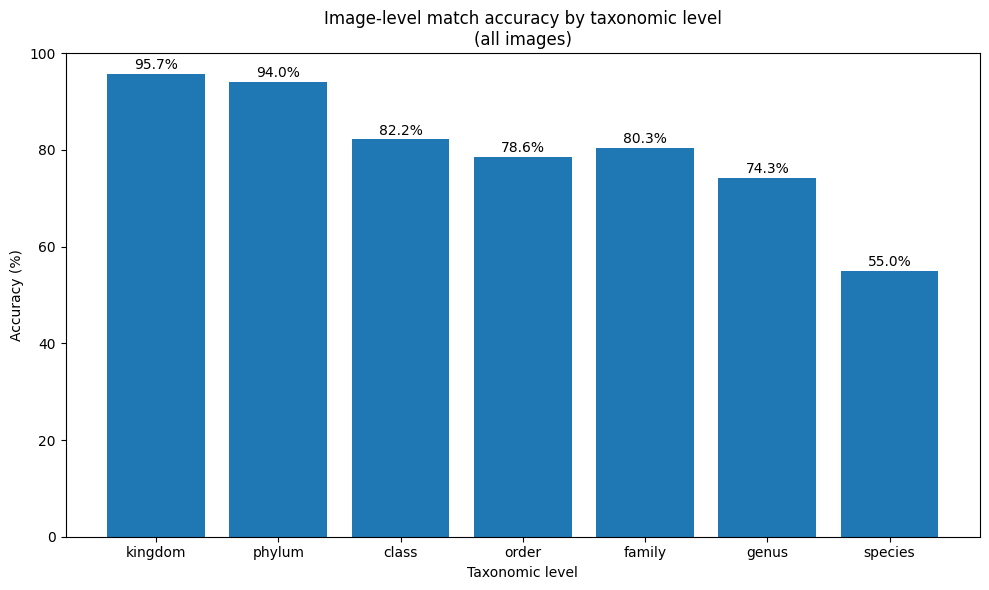

In [41]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_whole_df["Level"], accuracy_whole_df["Accuracy_%"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Taxonomic level")
plt.title("Image-level match accuracy by taxonomic level\n(all images)")
plt.ylim(0, 100)

for i, v in enumerate(accuracy_whole_df["Accuracy_%"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()


## MATCH COUNTS BY LEVEL

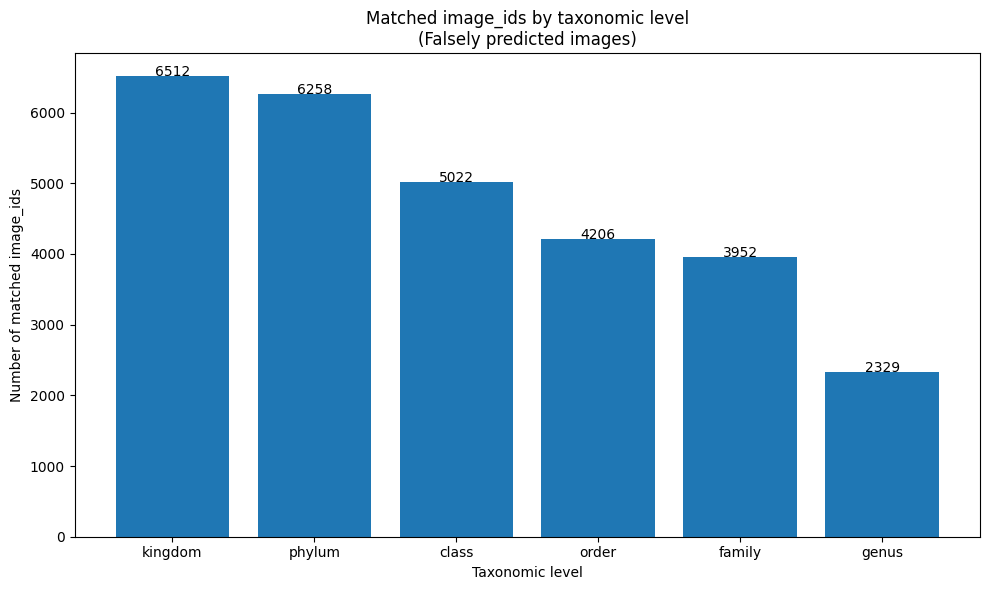

In [98]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_false_df["Level"], accuracy_false_df["Matched_image_ids"])
plt.ylabel("Number of matched image_ids")
plt.xlabel("Taxonomic level")
plt.title("Matched image_ids by taxonomic level\n(Falsely predicted images)")

for i, v in enumerate(accuracy_false_df["Matched_image_ids"]):
    plt.text(i, v + 0.2, str(v), ha="center")

plt.tight_layout()
plt.show()

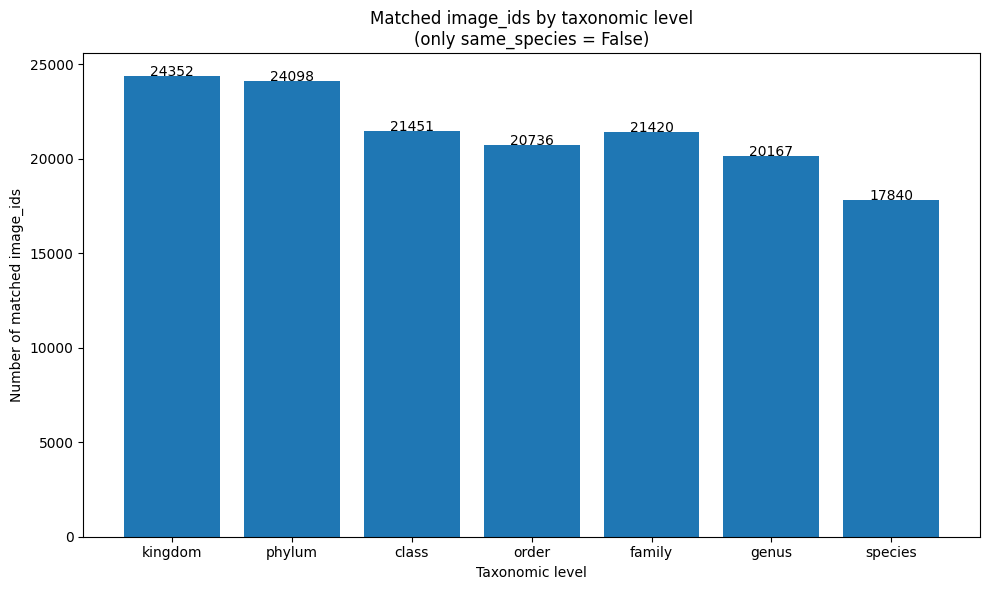

In [39]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_whole_df["Level"], accuracy_whole_df["Matched_image_ids"])
plt.ylabel("Number of matched image_ids")
plt.xlabel("Taxonomic level")
plt.title("Matched image_ids by taxonomic level\n(only same_species = False)")

for i, v in enumerate(accuracy_whole_df["Matched_image_ids"]):
    plt.text(i, v + 0.2, str(v), ha="center")

plt.tight_layout()
plt.show()

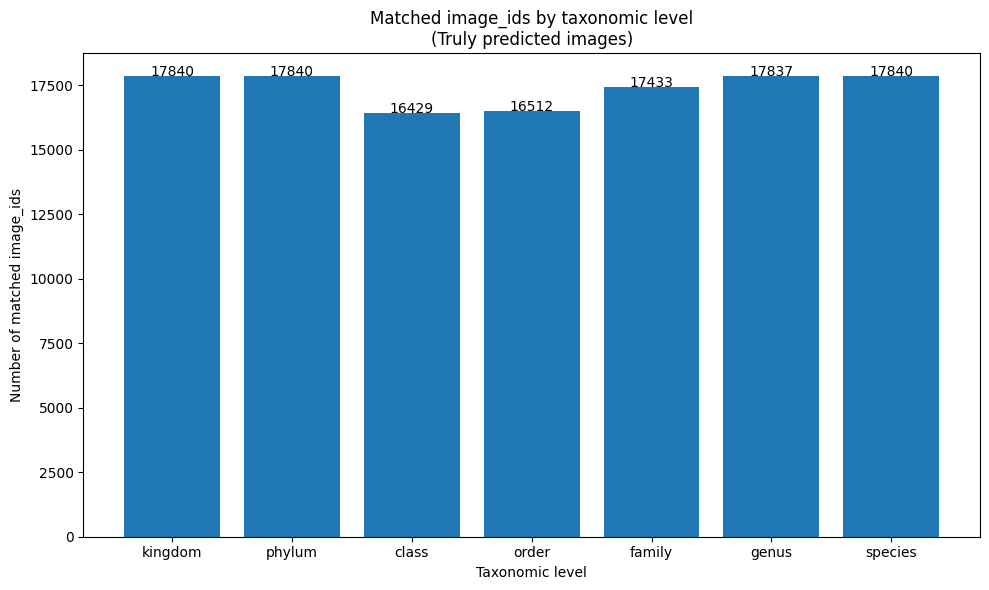

In [99]:
plt.figure(figsize=(10, 6))
plt.bar(accuracy_true_df["Level"], accuracy_true_df["Matched_image_ids"])
plt.ylabel("Number of matched image_ids")
plt.xlabel("Taxonomic level")
plt.title("Matched image_ids by taxonomic level\n(Truly predicted images)")

for i, v in enumerate(accuracy_true_df["Matched_image_ids"]):
    plt.text(i, v + 0.2, str(v), ha="center")

plt.tight_layout()
plt.show()

## IMAGE-LEVEL MATCH HEATMAP

In [40]:
# heatmap_df = image_level.set_index("image_id").astype(int)

# plt.figure(figsize=(12, max(6, len(heatmap_df) * 0.25)))
# plt.imshow(heatmap_df, aspect="auto")
# plt.colorbar(label="Match (1 = yes, 0 = no)")
# plt.xticks(
#     ticks=range(len(heatmap_df.columns)),
#     labels=[c.replace("_image_match", "") for c in heatmap_df.columns],
#     rotation=45
# )
# plt.yticks(ticks=range(len(heatmap_df.index)), labels=heatmap_df.index)
# plt.title("Image-level taxonomy match heatmap\n(only same_species = False)")
# plt.tight_layout()
# plt.show()

In [41]:
# heatmap_df = image_whole_level.set_index("image_id").astype(int)

# plt.figure(figsize=(12, max(6, len(heatmap_df) * 0.25)))
# plt.imshow(heatmap_df, aspect="auto")
# plt.colorbar(label="Match (1 = yes, 0 = no)")
# plt.xticks(
#     ticks=range(len(heatmap_df.columns)),
#     labels=[c.replace("_image_match", "") for c in heatmap_df.columns],
#     rotation=45
# )
# plt.yticks(ticks=range(len(heatmap_df.index)), labels=heatmap_df.index)
# plt.title("Image-level taxonomy match heatmap\n(only same_species = False)")
# plt.tight_layout()
# plt.show()

# Summary

In [42]:
print("\n=== Summary ===")
n_images = len(image_false_level)
best_level = accuracy_false_df.sort_values("Accuracy", ascending=False).iloc[0]
worst_level = accuracy_false_df.sort_values("Accuracy", ascending=True).iloc[0]

print(f"Total false-species image_ids analyzed: {n_images}")
print(f"Highest image-level match: {best_level['Level']} ({best_level['Accuracy_%']}%)")
print(f"Lowest image-level match: {worst_level['Level']} ({worst_level['Accuracy_%']}%)")


=== Summary ===
Total false-species image_ids analyzed: 11169
Highest image-level match: kingdom (90.33%)
Lowest image-level match: genus (42.86%)


In [43]:
print("\n=== Summary ===")
n_images = len(image_true_level)
best_level = accuracy_true_df.sort_values("Accuracy", ascending=False).iloc[0]
worst_level = accuracy_true_df.sort_values("Accuracy", ascending=True).iloc[0]

print(f"Total true-species image_ids analyzed: {n_images}")
print(f"Highest image-level match: {best_level['Level']} ({best_level['Accuracy_%']}%)")
print(f"Lowest image-level match: {worst_level['Level']} ({worst_level['Accuracy_%']}%)")


=== Summary ===
Total true-species image_ids analyzed: 13638
Highest image-level match: kingdom (100.0%)
Lowest image-level match: class (92.05%)


In [45]:
print("\n=== Summary ===")
n_images = len(image_false_level)
best_level = accuracy_whole_df.sort_values("Accuracy", ascending=False).iloc[0]
worst_level = accuracy_whole_df.sort_values("Accuracy", ascending=True).iloc[0]

print(f"Total false-species image_ids analyzed: {n_images}")
print(f"Highest image-level match: {best_level['Level']} ({best_level['Accuracy_%']}%)")
print(f"Lowest image-level match: {worst_level['Level']} ({worst_level['Accuracy_%']}%)")


=== Summary ===
Total false-species image_ids analyzed: 11169
Highest image-level match: kingdom (95.65%)
Lowest image-level match: species (54.98%)


# Analysis type distribution

In [44]:
analysis_df = df[(df["same_species?"]==False) & df["My analysis"].notna()]
len(analysis_df["My analysis"])

0

In [45]:
analysis_df["My analysis"].value_counts()

Series([], Name: count, dtype: int64)

In [46]:
analysis_df["My analysis"].unique()

array([], dtype=float64)

In [47]:
analysis_df["image_box"]=analysis_df["image_id"] + "_" + analysis_df["box_num"].astype(str)
analysis_df["image_box"].head(10)

Series([], Name: image_box, dtype: str)

In [48]:
analysis_df["image_box"].unique()

<StringArray>
[]
Length: 0, dtype: str

In [49]:
summary_dict={}


for image_box, group_df in analysis_df.groupby("image_box"):
    # print(image_box)
    # print(group_df)
    for i in range(len(group_df)-1):
        if group_df["My analysis"].iloc[i]=="Same genus but diff species":
            summary_dict["Same genus but diff species"]=summary_dict.get("Same genus but diff species",0)+1
        else:
            summary_dict[group_df["My analysis"].iloc[i]]=summary_dict.get(group_df["My analysis"].iloc[i],0)+1
print(summary_dict)


{}


In [50]:
summary_dict={}
    
for _, group_df in analysis_df.groupby("image_box"):
    if group_df["My analysis"].eq("Same genus but diff species").any():
        summary_dict["Same genus but diff species"]=summary_dict.get("Same genus but diff species",0)+1
    else:
        summary_dict[group_df["My analysis"].iloc[i]]=summary_dict.get(group_df["My analysis"].iloc[i],0)+1

print(summary_dict)

{}


In [51]:

df_summary = pd.DataFrame(
    summary_dict.items(),
    columns=["Category", "Count"]
)


In [52]:

total = df_summary["Count"].sum()
print("Total:", total)
df_summary["Percentage"] = (df_summary["Count"] / total) * 100

print(df_summary)


Total: 0
Empty DataFrame
Columns: [Category, Count, Percentage]
Index: []


In [ ]:
group_mapping = {
    "Group 1: Same genus but diff species": [
        "Same genus but diff species"
    ],
    "Group 2: Species is small part of the box": [
        "Species is small part of the box",
        "Species is small part of the box. Fungus."
    ],
    "Group 3: Species features not very clear": [
        "Species features not very clear",
        "Species is small part of the box; Species features not very clear",
        "Species is small part of the box. Fungus; Species features not very clear"
    ],
    "Group 4: Misidentified as different species": [
        "Misidentified as different species"
    ],
    "Group 5: Species not in the box": [
        "Species not in the box"
    ]
}

# -----------------------------
# 3. Compute grouped stats
# -----------------------------
rows = []

for group_name, notes in group_mapping.items():
    count = analysis_df[analysis_df["My analysis"].isin(notes)].shape[0]
    
    rows.append({
        "Group": group_name,
        "Count": count,
        "% of false": round((count / len(true_df)) * 100, 2) if len(true_df) else 0,
        "% of total": round((count / total) * 100, 2) if total else 0
    })

grouped_stats = pd.DataFrame(rows)

print(grouped_stats)

                                         Group  Count  % of false  % of total
0         Group 1: Same genus but diff species      0         0.0           0
1    Group 2: Species is small part of the box      0         0.0           0
2     Group 3: Species features not very clear      0         0.0           0
3  Group 4: Misidentified as different species      0         0.0           0
4              Group 5: Species not in the box      0         0.0           0


# Which category was rightly classified?


In [107]:
df

,crop_file,crop_file_path,image_id,Falsely identified,box_num,species,User_classified,same_species?,My analysis,common_name,...,order_row_match,family_pred_norm,family_user_norm,family_row_match,genus_pred_norm,genus_user_norm,genus_row_match,species_pred_norm,species_user_norm,species_row_match
0,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Cerocala contraria,Eudocima divitiosa,False,NaN,NaN,...,True,erebidae,erebidae,True,cerocala,eudocima,False,cerocala contraria,eudocima divitiosa,False
1,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Chrysorithrum flavomaculata,Eudocima divitiosa,False,NaN,NaN,...,True,erebidae,erebidae,True,chrysorithrum,eudocima,False,chrysorithrum flavomaculata,eudocima divitiosa,False
2,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Ulotrichopus marmoratus,Eudocima divitiosa,False,NaN,NaN,...,True,erebidae,erebidae,True,ulotrichopus,eudocima,False,ulotrichopus marmoratus,eudocima divitiosa,False
3,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima divitiosa,Eudocima divitiosa,True,NaN,NaN,...,True,erebidae,erebidae,True,eudocima,eudocima,True,eudocima divitiosa,eudocima divitiosa,True
4,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima colubra,Eudocima divitiosa,False,NaN,NaN,...,True,erebidae,erebidae,True,eudocima,eudocima,True,eudocima colubra,eudocima divitiosa,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373725,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco porphyreolophus,Gallirex porphyreolophus,False,NaN,Purple-crested Turaco,...,True,musophagidae,musophagidae,True,tauraco,gallirex,False,tauraco porphyreolophus,gallirex porphyreolophus,False
373726,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco hartlaubi,Gallirex porphyreolophus,False,NaN,Hartlaub's Turaco,...,True,musophagidae,musophagidae,True,tauraco,gallirex,False,tauraco hartlaubi,gallirex porphyreolophus,False
373727,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco erythrolophus,Gallirex porphyreolophus,False,NaN,Red-crested Turaco,...,True,musophagidae,musophagidae,True,tauraco,gallirex,False,tauraco erythrolophus,gallirex porphyreolophus,False
373728,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco fischeri,Gallirex porphyreolophus,False,NaN,Fischer's turaco,...,True,musophagidae,musophagidae,True,tauraco,gallirex,False,tauraco fischeri,gallirex porphyreolophus,False


In [55]:
match_df = df[df["Falsely identified"]=="Match"]
match_df

,crop_file,crop_file_path,image_id,Falsely identified,box_num,species,User_classified,same_species?,My analysis,common_name,...,order_row_match,family_pred_norm,family_user_norm,family_row_match,genus_pred_norm,genus_user_norm,genus_row_match,species_pred_norm,species_user_norm,species_row_match
0,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Cerocala contraria,Eudocima divitiosa,False,NaN,NaN,...,True,erebidae,erebidae,True,cerocala,eudocima,False,cerocala contraria,eudocima divitiosa,False
1,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Chrysorithrum flavomaculata,Eudocima divitiosa,False,NaN,NaN,...,True,erebidae,erebidae,True,chrysorithrum,eudocima,False,chrysorithrum flavomaculata,eudocima divitiosa,False
2,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Ulotrichopus marmoratus,Eudocima divitiosa,False,NaN,NaN,...,True,erebidae,erebidae,True,ulotrichopus,eudocima,False,ulotrichopus marmoratus,eudocima divitiosa,False
3,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima divitiosa,Eudocima divitiosa,True,NaN,NaN,...,True,erebidae,erebidae,True,eudocima,eudocima,True,eudocima divitiosa,eudocima divitiosa,True
4,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima colubra,Eudocima divitiosa,False,NaN,NaN,...,True,erebidae,erebidae,True,eudocima,eudocima,True,eudocima colubra,eudocima divitiosa,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373590,obs_99944557_photo_166725516_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99944557_photo_166725516,Match,2,Anolis sagrei,Anolis sagrei,True,NaN,Brown anole,...,False,dactyloidae,anolidae,False,anolis,anolis,True,anolis sagrei,anolis sagrei,True
373591,obs_99944557_photo_166725516_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99944557_photo_166725516,Match,2,Anolis carolinensis,Anolis sagrei,False,NaN,Green anole,...,False,dactyloidae,anolidae,False,anolis,anolis,True,anolis carolinensis,anolis sagrei,False
373592,obs_99944557_photo_166725516_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99944557_photo_166725516,Match,2,Anolis ustus,Anolis sagrei,False,NaN,NaN,...,False,dactyloidae,anolidae,False,anolis,anolis,True,anolis ustus,anolis sagrei,False
373593,obs_99944557_photo_166725516_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99944557_photo_166725516,Match,2,Anolis homolechis,Anolis sagrei,False,NaN,Habana anole,...,False,dactyloidae,anolidae,False,anolis,anolis,True,anolis homolechis,anolis sagrei,False


In [115]:
user_col = 'user_phylum'
match_col = 'same_species?'
status_col = 'Falsely identified'

In [116]:
s = df.copy()
s['match_norm'] = s[match_col].astype(str).str.strip().str.lower()
s['status_norm'] = s[status_col].astype(str).str.strip().str.lower()
s

,crop_file,crop_file_path,image_id,Falsely identified,box_num,species,User_classified,same_species?,My analysis,common_name,...,family_user_norm,family_row_match,genus_pred_norm,genus_user_norm,genus_row_match,species_pred_norm,species_user_norm,species_row_match,match_norm,status_norm
0,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Cerocala contraria,Eudocima divitiosa,False,NaN,NaN,...,erebidae,True,cerocala,eudocima,False,cerocala contraria,eudocima divitiosa,False,false,match
1,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Chrysorithrum flavomaculata,Eudocima divitiosa,False,NaN,NaN,...,erebidae,True,chrysorithrum,eudocima,False,chrysorithrum flavomaculata,eudocima divitiosa,False,false,match
2,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Ulotrichopus marmoratus,Eudocima divitiosa,False,NaN,NaN,...,erebidae,True,ulotrichopus,eudocima,False,ulotrichopus marmoratus,eudocima divitiosa,False,false,match
3,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima divitiosa,Eudocima divitiosa,True,NaN,NaN,...,erebidae,True,eudocima,eudocima,True,eudocima divitiosa,eudocima divitiosa,True,true,match
4,obs_10003229_photo_114145431_box1.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_10003229_photo_114145431,Match,1,Eudocima colubra,Eudocima divitiosa,False,NaN,NaN,...,erebidae,True,eudocima,eudocima,True,eudocima colubra,eudocima divitiosa,False,false,match
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
373725,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco porphyreolophus,Gallirex porphyreolophus,False,NaN,Purple-crested Turaco,...,musophagidae,True,tauraco,gallirex,False,tauraco porphyreolophus,gallirex porphyreolophus,False,false,no match
373726,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco hartlaubi,Gallirex porphyreolophus,False,NaN,Hartlaub's Turaco,...,musophagidae,True,tauraco,gallirex,False,tauraco hartlaubi,gallirex porphyreolophus,False,false,no match
373727,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco erythrolophus,Gallirex porphyreolophus,False,NaN,Red-crested Turaco,...,musophagidae,True,tauraco,gallirex,False,tauraco erythrolophus,gallirex porphyreolophus,False,false,no match
373728,obs_99990956_photo_166796345_box2.jpg,/rs1/researchers/a/amallav/results/outputs_cro...,obs_99990956_photo_166796345,No Match,2,Tauraco fischeri,Gallirex porphyreolophus,False,NaN,Fischer's turaco,...,musophagidae,True,tauraco,gallirex,False,tauraco fischeri,gallirex porphyreolophus,False,false,no match


In [118]:
# counts for exact statuses (case-insensitive)
match_counts = s[s['match_norm'] == 'true'].groupby(s[user_col].fillna('Unknown')).size()
no_match_counts = s[s['status_norm'] == 'no match'].groupby(s[user_col].fillna('Unknown')).size()
total_counts = match_counts + no_match_counts
match_counts, no_match_counts, total_counts

(user_phylum
 Annelida              23
 Arthropoda         14541
 Ascomycota           113
 Basidiomycota        140
 Chordata           15735
 Cnidaria              24
 Echinodermata        101
 Mollusca             302
 Nemertea               6
 Ochrophyta             5
 Onychophora           56
 Platyhelminthes       28
 Proteobacteria         6
 Tracheophyta        8097
 dtype: int64,
 user_phylum
 Annelida                  95
 Arthropoda             40985
 Ascomycota              5515
 Basidiomycota            610
 Chordata               31915
 Cnidaria                 335
 Echinodermata            205
 Entomophthoromycota      310
 Mollusca                1025
 Mycetozoa                 85
 Onychophora              290
 Oomycota                  60
 Pisuviricota               5
 Platyhelminthes          155
 Proteobacteria            15
 Tracheophyta           22340
 dtype: int64,
 user_phylum
 Annelida                 118.0
 Arthropoda             55526.0
 Ascomycota            

In [119]:
summary = pd.DataFrame({
    'user_phylum': total_counts.index,
    'match_count': match_counts.reindex(total_counts.index, fill_value=0).astype(int).values,
    'no_match_count': no_match_counts.reindex(total_counts.index, fill_value=0).astype(int).values,
    'total_count': total_counts.values
})


In [120]:
summary['pct_match'] = (summary['match_count'] / summary['total_count'] * 100).round(2)
summary['pct_no_match'] = (summary['no_match_count'] / summary['total_count'] * 100).round(2)

summary = summary.sort_values('total_count', ascending=False).reset_index(drop=True)
summary

,user_phylum,match_count,no_match_count,total_count,pct_match,pct_no_match
0,Arthropoda,14541,40985,55526.0,26.19,73.81
1,Chordata,15735,31915,47650.0,33.02,66.98
2,Tracheophyta,8097,22340,30437.0,26.60,73.40
3,Ascomycota,113,5515,5628.0,2.01,97.99
4,Mollusca,302,1025,1327.0,22.76,77.24
5,Basidiomycota,140,610,750.0,18.67,81.33
6,Cnidaria,24,335,359.0,6.69,93.31
7,Onychophora,56,290,346.0,16.18,83.82
8,Echinodermata,101,205,306.0,33.01,66.99
9,Platyhelminthes,28,155,183.0,15.30,84.70
